# FunnelIQ — Package 4: The "Super Customer" Score

**Goal (from the brief):** target = `referred`. Super customers stay long, buy more, and bring
in new clients. **Prediction moment: early** -- *"given a new customer's early funnel data,
output a 0-100 likelihood."* Per the leakage decisions, this is **the strictest package** -- only
early-funnel data is fair game, not the fuller Tier 1-3 set Packages 2 and 3 used.

**Deliverable:** a CatBoost classifier with an engineered categorical budget-tier feature
(Low/Mid/High) that CatBoost handles natively, tuned via a hyperparameter search over learning
rate, depth, and iterations. Then a scoring pipeline: given a new customer's early funnel data,
output a 0-100 likelihood of becoming a super customer.

**Questions the brief asks us to answer:**
1. Profile the super customers (`referred=Yes`, `upsell=1`, long tenure): what share of total
   profit do they represent, and what's their average acquisition cost?
2. How could Northbound spot them earlier?

Builds on [[`02 Leakage Decisions`]] / `funneliq_leakage_decisions.md` and reuses the pattern from
[`03_Package2_LTV_Regression.ipynb`](./03_Package2_LTV_Regression.ipynb) and
[`04_Package3_Upsell_Classification.ipynb`](./04_Package3_Upsell_Classification.ipynb).


## 1. A new decision: filter to `purchased == 1`

The leakage doc didn't pin this down for Package 4 the way it explicitly did for Package 3, so
it's worth checking the data before deciding. "Referring" is something a customer does -- does it
make sense to include people who never bought anything?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("funnel_marketing_data.csv").drop_duplicates().reset_index(drop=True)
print(f"rows after dedupe: {len(df)}")

pd.crosstab(df["purchased"], df["referred"])


rows after dedupe: 3490


referred,No,Yes
purchased,,
0,324,3
1,1812,1351


**Decision: filter to `purchased == 1`.** Not as clean-cut as Package 3's deterministic
`purchased==0 -> upsell==0` (this time it's 324 of 327 non-purchasers, 99.1%, not literally all of
them) -- but the pattern is overwhelming, and the business logic is the same: the brief's own
framing is "given a **new customer's** early funnel data," and a non-purchaser isn't a customer
yet. Training on the 3 non-purchaser exceptions would add noise without adding a real,
generalizable pattern.


In [2]:
df_p = df[df["purchased"] == 1].reset_index(drop=True)
print(f"rows with purchased == 1: {len(df_p)}")


rows with purchased == 1: 3163


## 2. The strict feature cut -- only genuinely *early* data

Packages 2 and 3 allowed all of Tier 1-3 (funnel inputs, funnel process, acquisition facts).
Package 4 does not: the brief explicitly wants a score computable from a customer's **early**
funnel data, and the leakage decisions flagged `closed`, `calls_to_closed`,
`customer_acquisition_cost`, and the rest of Tier 2/3 as **conditional** -- allowed only if
justified as genuinely early.

**Decision: none of them qualify.** `calls_to_closed` only exists once the sales process has
finished; `customer_acquisition_cost` is only known once the deal is priced out; `closed` is
almost the definition of "not early." Using any of them would defeat the entire point of scoring
customers *earlier* than the funnel process reveals the answer on its own. So Package 4 uses only
**Tier 1** -- `ad_budget`, `num_leads`, `leads_answered`, `leads_not_answered` -- plus one
engineered feature below.


## 3. Engineer the budget-tier feature

The brief's specific ask: *"engineer a categorical budget-tier feature (Low/Mid/High) and let
CatBoost handle it natively."* Same thresholds used throughout this project (Package 1's EDA,
Package 6's brief description): Low ≤ ₪1,500, Mid ₪2,000-5,000, High > ₪5,000.


In [3]:
def budget_tier(x):
    if x <= 1500:
        return "Low"
    elif x <= 5000:
        return "Mid"
    else:
        return "High"

df_p["budget_tier"] = df_p["ad_budget"].apply(budget_tier)
df_p["budget_tier"].value_counts()


budget_tier
Mid     1640
High     952
Low      571
Name: count, dtype: int64

`ad_budget` (numeric) and `budget_tier` (categorical, derived from it) both stay in the feature
set -- redundant information isn't a problem for CatBoost's tree splits (the same reasoning
already applied to `num_leads`'s exact relationship with `leads_answered` + `leads_not_answered`
back in Package 1/2), and the brief specifically wants the *engineered* categorical version
exercised, not a replacement for the raw number.


## 4. Class balance



In [4]:
y_counts = df_p["referred"].value_counts()
y_props = df_p["referred"].value_counts(normalize=True).round(3)
pd.DataFrame({"count": y_counts, "proportion": y_props})


,count,proportion
referred,,
No,1812,0.573
Yes,1351,0.427


57.3% / 42.7% -- close enough to even that, same as Package 3's reasoning, no imbalance handling
is warranted.


## 5. Hyperparameter tuning

**A real technical snag worth documenting**: `sklearn`'s `GridSearchCV` / `cross_validate` both
call `clone()` on the estimator internally, and CatBoost's sklearn wrapper doesn't round-trip the
`cat_features` constructor argument the way current `scikit-learn` expects -- it raises
`RuntimeError: Cannot clone object ... constructor either does not set or modifies parameter
cat_features`. Rather than fight that incompatibility, the search below is a **plain manual grid
search**: loop over parameter combinations, run stratified 5-fold CV by hand (constructing a
fresh `CatBoostClassifier` per fold instead of relying on `clone()`), and record the mean
validation ROC-AUC per combination. Arguably clearer to read than a black-box `GridSearchCV` call
anyway.

Grid: `learning_rate` in {0.01, 0.05, 0.1}, `depth` in {4, 6, 8}, `iterations` in {200, 400} -- 18
combinations, matching the brief's named hyperparameters.


In [5]:
import itertools
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from catboost import CatBoostClassifier

feature_cols = ["ad_budget", "num_leads", "leads_answered", "leads_not_answered", "budget_tier"]
cat_features = ["budget_tier"]

X = df_p[feature_cols]
y = (df_p["referred"] == "Yes").astype(int)

param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8],
    "iterations": [200, 400],
}
keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"{len(combos)} combinations")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(cv.split(X, y))

search_results = []
for combo in combos:
    params = dict(zip(keys, combo))
    fold_aucs = []
    for train_idx, val_idx in splits:
        model = CatBoostClassifier(**params, cat_features=cat_features, random_state=42, verbose=False)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y.iloc[val_idx], proba))
    search_results.append({**params, "mean_roc_auc": np.mean(fold_aucs)})

search_df = pd.DataFrame(search_results).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)
search_df.head(10)


18 combinations


,learning_rate,depth,iterations,mean_roc_auc
0,0.01,8,400,0.775903
1,0.01,4,400,0.775766
2,0.01,6,400,0.775359
3,0.01,8,200,0.774824
4,0.01,6,200,0.774412
5,0.05,4,200,0.774015
6,0.01,4,200,0.773777
7,0.05,6,200,0.772283
8,0.05,8,200,0.770381
9,0.05,6,400,0.768844


In [6]:
best_params = search_df.iloc[0][keys].to_dict()
best_params = {k: (int(v) if k in ("depth", "iterations") else v) for k, v in best_params.items()}
print("best params:", best_params)
print("best mean CV ROC-AUC:", search_df.iloc[0]["mean_roc_auc"])


best params: {'learning_rate': 0.01, 'depth': 8, 'iterations': 400}
best mean CV ROC-AUC: 0.7759032670366175


**Reading this:** the top handful of combinations are within a hair of each other (ROC-AUC
0.774-0.776) -- tuning helps at the margin here, not dramatically. Worth confirming that margin is
real rather than noise, by comparing against CatBoost's untuned defaults.


In [7]:
untuned_aucs = []
for train_idx, val_idx in splits:
    model = CatBoostClassifier(cat_features=cat_features, random_state=42, verbose=False)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    proba = model.predict_proba(X.iloc[val_idx])[:, 1]
    untuned_aucs.append(roc_auc_score(y.iloc[val_idx], proba))

print(f"untuned default ROC-AUC: {np.mean(untuned_aucs):.4f}")
print(f"tuned ROC-AUC: {search_df.iloc[0]['mean_roc_auc']:.4f}")


untuned default ROC-AUC: 0.7679
tuned ROC-AUC: 0.7759


Tuning adds a real but modest lift (~0.008 ROC-AUC over the untuned default) -- an honest result:
this dataset's signal is strong enough that CatBoost's defaults already capture most of it, and
the brief's hyperparameter search earns a small, not a dramatic, improvement. Reporting that
honestly beats implying tuning did more than it did.


## 6. Full metrics for the tuned model



In [8]:
metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "roc_auc": []}
for train_idx, val_idx in splits:
    model = CatBoostClassifier(**best_params, cat_features=cat_features, random_state=42, verbose=False)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    proba = model.predict_proba(X.iloc[val_idx])[:, 1]
    pred = (proba >= 0.5).astype(int)
    yv = y.iloc[val_idx]
    metrics["accuracy"].append(accuracy_score(yv, pred))
    metrics["precision"].append(precision_score(yv, pred))
    metrics["recall"].append(recall_score(yv, pred))
    metrics["f1"].append(f1_score(yv, pred))
    metrics["roc_auc"].append(roc_auc_score(yv, proba))

majority_baseline = y.value_counts(normalize=True).max()
summary = pd.Series({k: np.mean(v) for k, v in metrics.items()})
summary["majority_baseline_accuracy"] = majority_baseline
summary.round(4)


accuracy                      0.7512
precision                     0.6723
recall                        0.8157
f1                            0.7370
roc_auc                       0.7759
majority_baseline_accuracy    0.5729
dtype: float64

Accuracy 0.751 against a 0.573 majority baseline -- a real lift, though smaller than Package 3's
gap over its baseline, consistent with this being a harder, more early-signal-only problem by
design (that's the cost of restricting to genuinely early features -- less information, so less
separability, which is expected and correct, not a bug).


## 7. Feature importance -- one feature dominates, and it connects back to Package 1



In [9]:
final_model = CatBoostClassifier(**best_params, cat_features=cat_features, random_state=42, verbose=False)
final_model.fit(X, y)

importances = final_model.get_feature_importance()
imp_series = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
imp_series


budget_tier           75.351103
leads_answered         8.528493
leads_not_answered     5.690153
num_leads              5.541354
ad_budget              4.888897
dtype: float64

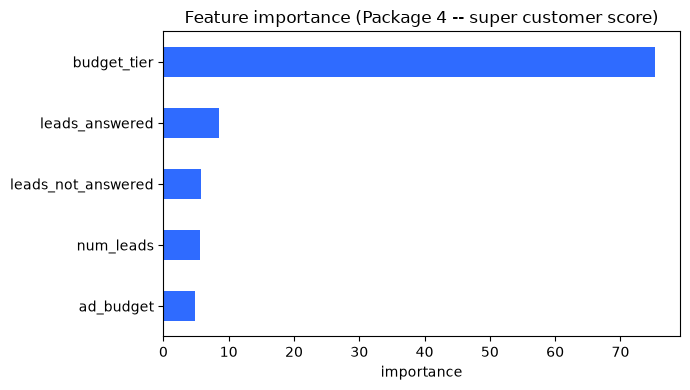

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
imp_series.plot(kind="barh", ax=ax, color="#2f6bff")
ax.set_xlabel("importance")
ax.set_title("Feature importance (Package 4 -- super customer score)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**`budget_tier` alone accounts for ~75% of the model's importance** -- the engineered categorical
feature the brief specifically asked for turns out to be by far the strongest signal available
this early, dwarfing the raw numeric features. This connects directly back to
[`02_EDA_and_Cleaning.ipynb`](./02_EDA_and_Cleaning.ipynb)'s Package 1 finding that conversion
rate is **non-monotonic** in budget -- Mid-tier budgets converted best, not High. The same
non-monotonic pattern is apparently even more pronounced for who becomes a super customer: which
budget bucket a campaign falls into predicts referral behavior far better than how many leads or
how much budget in absolute terms.


## 8. The scoring pipeline -- 0-100 likelihood

The brief's exact deliverable: given a new customer's early funnel data, output a 0-100
likelihood of becoming a super customer. That's just `predict_proba` scaled.


In [11]:
def super_customer_score(row: dict) -> float:
    """row must have ad_budget, num_leads, leads_answered, leads_not_answered."""
    row = dict(row)
    row["budget_tier"] = budget_tier(row["ad_budget"])
    x = pd.DataFrame([row])[feature_cols]
    return round(float(final_model.predict_proba(x)[0][1]) * 100, 1)

# Sanity check against a few real customers
sample = df_p.sample(5, random_state=1)
scores = [
    super_customer_score({
        "ad_budget": r.ad_budget, "num_leads": r.num_leads,
        "leads_answered": r.leads_answered, "leads_not_answered": r.leads_not_answered,
    })
    for r in sample.itertuples()
]
pd.DataFrame({
    "actual_referred": sample["referred"].values,
    "score_0_100": scores,
})


,actual_referred,score_0_100
0,Yes,23.2
1,Yes,70.2
2,No,69.0
3,No,14.7
4,No,19.1


## 9. Answering the brief's questions

**Profile the super customers** (`referred=Yes` AND `upsell=1` AND long tenure). "Long tenure"
needs a concrete definition -- using **above the dataset's median `ltv_months` (21 months)** as
the cutoff, applied to the full deduped dataset (this profiling is descriptive, like Packages 1
and 5, so the leakage/early-only restriction doesn't apply here -- we're describing who these
customers turned out to be, not predicting it in advance).


In [12]:
median_ltv = df["ltv_months"].median()
super_mask = (df["referred"] == "Yes") & (df["upsell"] == 1) & (df["ltv_months"] > median_ltv)

n_super = super_mask.sum()
print(f"super customers: {n_super} of {len(df)} ({n_super/len(df):.1%})")

total_profit = df["cumulative_profit"].sum()
super_profit = df.loc[super_mask, "cumulative_profit"].sum()
print(f"share of total profit: {super_profit/total_profit:.1%}")

print(f"avg CAC, super customers: {df.loc[super_mask, 'customer_acquisition_cost'].mean():.0f}")
print(f"avg CAC, everyone else:   {df.loc[~super_mask, 'customer_acquisition_cost'].mean():.0f}")


super customers: 944 of 3490 (27.0%)
share of total profit: 53.6%
avg CAC, super customers: 1003
avg CAC, everyone else:   1510


**Super customers are 27% of all customers but generate 53.6% of total profit** -- over half the
business's profit comes from roughly a quarter of customers. And they're **cheaper to acquire**,
not more expensive: ~₪1,003 average CAC vs. ~₪1,510 for everyone else. This is a striking,
counter-intuitive finding worth leading with in `REPORT.md`: the most valuable customers aren't
the ones Northbound spent the most to win.

**How could Northbound spot them earlier?** Two converging pieces of evidence point the same
direction:
1. **`budget_tier` dominates the early-signal model** (Section 7) -- campaigns in the Mid budget
   bucket are disproportionately likely to produce a future super customer, echoing Package 1's
   conversion-rate finding.
2. **Super customers are the cheap-to-acquire ones** (this section) -- low CAC isn't just
   correlated with long tenure and upsell (Packages 2 and 3 already found `calls_to_closed` and
   CAC as top levers there too); it's also a marker of eventual referral behavior.

Putting them together: Northbound doesn't need to wait for a customer to convert, upsell, or stay
a year to guess whether they're a future super customer. The `budget_tier` of the campaign that
brought them in, combined with an early read on how cheaply they're converting, is already a
meaningful signal -- exactly what this Package 4 score is built to surface at the moment a
customer first shows up.


## 10. Saving the model to serve

Same convention as Packages 2 and 3.


In [13]:
import json
import platform
from datetime import datetime, timezone
from pathlib import Path

import joblib
import sklearn
import catboost

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "super_customer_classifier.pkl"
joblib.dump(final_model, model_path)

meta = {
    "package": 4,
    "target": "referred",
    "row_filter": "purchased == 1",
    "model_type": "CatBoost",
    "feature_columns": feature_cols,
    "categorical_features": cat_features,
    "engineered_features": {"budget_tier": "Low <=1500, Mid 2000-5000, High >5000 (from ad_budget)"},
    "training_row_count": len(df_p),
    "cv_folds": 5,
    "cv_strategy": "StratifiedKFold",
    "selection_metric": "roc_auc",
    "hyperparameters": best_params,
    "cv_metrics": {k: float(v) for k, v in summary.drop("majority_baseline_accuracy").items()},
    "majority_baseline_accuracy": float(majority_baseline),
    "untuned_default_roc_auc": float(np.mean(untuned_aucs)),
    "library_versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "catboost": catboost.__version__,
    },
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
}
meta_path = models_dir / "super_customer_classifier_meta.json"
meta_path.write_text(json.dumps(meta, indent=2))

print(f"saved: {model_path}")
print(f"saved: {meta_path}")


saved: models/super_customer_classifier.pkl
saved: models/super_customer_classifier_meta.json


### Verify the saved artifact works



In [14]:
reloaded = joblib.load("models/super_customer_classifier.pkl")

sample2 = df_p.sample(5, random_state=7)
proba2 = reloaded.predict_proba(sample2[feature_cols])[:, 1]

pd.DataFrame({
    "actual_referred": sample2["referred"].values,
    "score_0_100": (proba2 * 100).round(1),
})


,actual_referred,score_0_100
0,Yes,68.4
1,No,11.6
2,No,10.9
3,No,10.7
4,Yes,69.3


## 11. What's next

Trained, tuned, answered the brief's questions, and saved `models/super_customer_classifier.pkl`
+ meta.json. Not yet done:
- A `POST /predict/super_customer` endpoint (same Supabase-session auth pattern as `/predict/ltv`
  and `/predict/upsell`) and a matching dashboard section.
- Folding these findings -- especially the profit/CAC profile in Section 9 -- into `REPORT.md`.
